# Gradient flow

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# Define the function
def function(w1, w2):
    return w1**2 + w2**2

# Compute the gradient of the function
def gradient(w1, w2):
    df_dw1 = 2 * w1  # Partial derivative w.r.t. w1
    df_dw2 = 2 * w2  # Partial derivative w.r.t. w2
    return np.array([df_dw1, df_dw2])

# Create a grid of points
w1_values = np.linspace(-5, 5, 20)
w2_values = np.linspace(-5, 5, 20)
W1, W2 = np.meshgrid(w1_values, w2_values)

w1_values

array([-5.        , -4.47368421, -3.94736842, -3.42105263, -2.89473684,
       -2.36842105, -1.84210526, -1.31578947, -0.78947368, -0.26315789,
        0.26315789,  0.78947368,  1.31578947,  1.84210526,  2.36842105,
        2.89473684,  3.42105263,  3.94736842,  4.47368421,  5.        ])

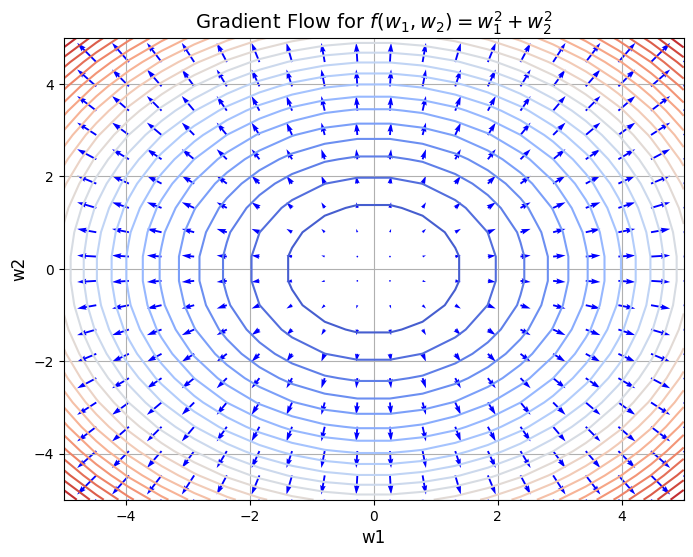

In [25]:
# Create a grid of points
w1_values = np.linspace(-5, 5, 20)
w2_values = np.linspace(-5, 5, 20)
W1, W2 = np.meshgrid(w1_values, w2_values)

# Compute the function value at each point on the grid
Z = function(W1, W2)

# Compute the gradient at each point on the grid
U, V = np.zeros(W1.shape), np.zeros(W1.shape)
for i in range(W1.shape[0]):
    for j in range(W1.shape[1]):
        grad = gradient(W1[i, j], W2[i, j])
        U[i, j] = grad[0]
        V[i, j] = grad[1]

# Create the plot
plt.figure(figsize=(8, 6))

# Plot the function contours
plt.contour(W1, W2, Z, levels=30, cmap='coolwarm')

# Plot the gradient field (using quiver for arrows)
plt.quiver(W1, W2, U, V, color='blue')

# Set axis labels and title
plt.xlabel('w1', fontsize=12)
plt.ylabel('w2', fontsize=12)
plt.title('Gradient Flow for $f(w_1, w_2) = w_1^2 + w_2^2$', fontsize=14)

# Show the plot
plt.grid(True)
plt.show()

# Gradient descent illustrations

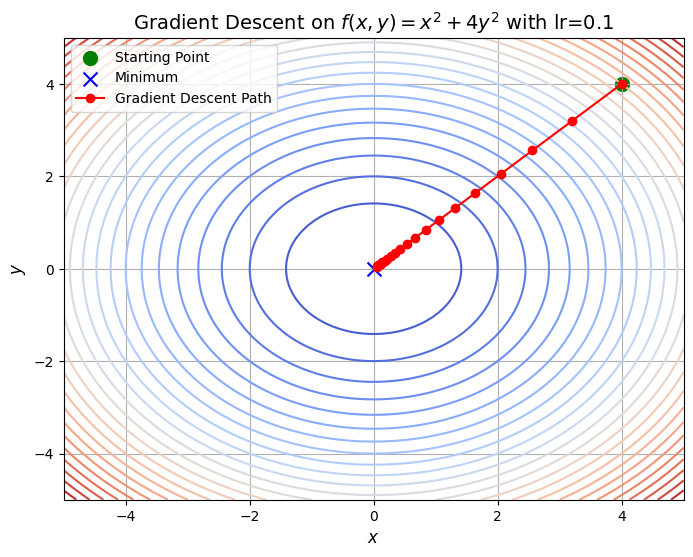

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation

# Define the 2D function to minimize (a simple paraboloid)
def function(x, y):
    return x**2 + y**2

# Compute the gradient of the function
def gradient(x, y):
    df_dx = 2 * x
    df_dy = 2 * y
    return np.array([df_dx, df_dy])

# Gradient descent parameters
learning_rate = 0.1
n_iterations = 20

# Initialize a starting point for the gradient descent
initial_point = np.array([4.0, 4.0])  # Starting at (4, 4)

# List to store the points during the descent
points = [initial_point]

# Perform gradient descent
for i in range(n_iterations):
    current_point = points[-1]
    grad = gradient(current_point[0], current_point[1])
    new_point = current_point - learning_rate * grad  # Update rule
    points.append(new_point)

# Convert the points to a numpy array for easier plotting
points = np.array(points)

# Create a grid of points to evaluate the function for contour plotting
x_values = np.linspace(-5, 5, 100)
y_values = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x_values, y_values)
Z = function(X, Y)

# Create the figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the contour of the function
contour = ax.contour(X, Y, Z, levels=30, cmap='coolwarm')

# Plot the starting point and the minimum
ax.scatter(initial_point[0], initial_point[1], color='green', marker='o', label='Starting Point', s=100)
ax.scatter(0, 0, color='blue', marker='x', label='Minimum', s=100)

# Create an empty line for the path of gradient descent
path, = ax.plot([], [], 'ro-', label='Gradient Descent Path')

# Set axis labels and title
ax.set_xlabel('$x$', fontsize=12)
ax.set_ylabel('$y$', fontsize=12)
ax.set_title(f'Gradient Descent on $f(x, y) = x^2 + 4y^2$ with lr={learning_rate}', fontsize=14)

# Add a legend
ax.legend()

# Set axis limits
ax.set_xlim([-5, 5])
ax.set_ylim([-5, 5])

# Animation function
def update(frame):
    path.set_data(points[:frame+1, 0], points[:frame+1, 1])
    return path,

# Create the animation
ani = FuncAnimation(fig, update, frames=len(points), interval=200, blit=True, repeat=False)

# Show the animation
plt.grid(True)

# Save the animation as a gif
ani.save(f'gradient_descent.gif', writer='pillow', fps=5)

# Display the plot (this will show a static image in some environments)
plt.show()

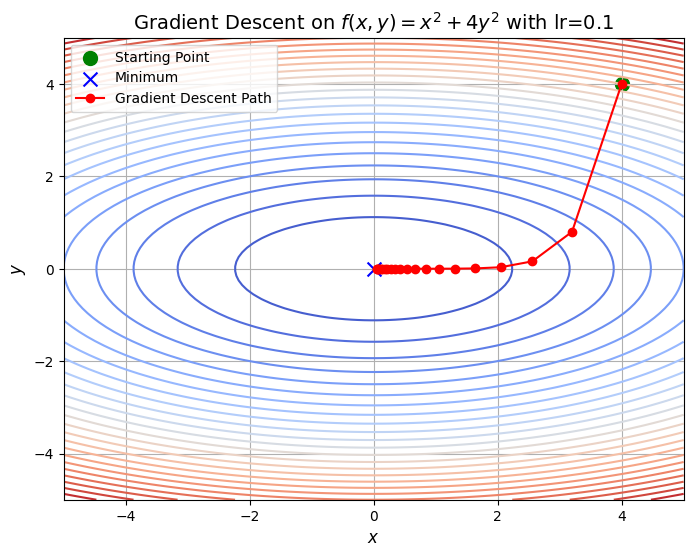

In [3]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation

# Define the 2D function to minimize (a simple paraboloid)
def function(x, y):
    return x**2 + 4*y**2

# Compute the gradient of the function
def gradient(x, y):
    df_dx = 2 * x
    df_dy = 8 * y
    return np.array([df_dx, df_dy])

# Gradient descent parameters
learning_rate = 0.1
n_iterations = 20

# Initialize a starting point for the gradient descent
initial_point = np.array([4.0, 4.0])  # Starting at (4, 4)

# List to store the points during the descent
points = [initial_point]

# Perform gradient descent
for i in range(n_iterations):
    current_point = points[-1]
    grad = gradient(current_point[0], current_point[1])
    new_point = current_point - learning_rate * grad  # Update rule
    points.append(new_point)

# Convert the points to a numpy array for easier plotting
points = np.array(points)

# Create a grid of points to evaluate the function for contour plotting
x_values = np.linspace(-5, 5, 100)
y_values = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x_values, y_values)
Z = function(X, Y)

# Create the figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the contour of the function
contour = ax.contour(X, Y, Z, levels=30, cmap='coolwarm')

# Plot the starting point and the minimum
ax.scatter(initial_point[0], initial_point[1], color='green', marker='o', label='Starting Point', s=100)
ax.scatter(0, 0, color='blue', marker='x', label='Minimum', s=100)

# Create an empty line for the path of gradient descent
path, = ax.plot([], [], 'ro-', label='Gradient Descent Path')

# Set axis labels and title
ax.set_xlabel('$x$', fontsize=12)
ax.set_ylabel('$y$', fontsize=12)
ax.set_title(f'Gradient Descent on $f(x, y) = x^2 + 4y^2$ with lr={learning_rate}', fontsize=14)

# Add a legend
ax.legend()

# Set axis limits
ax.set_xlim([-5, 5])
ax.set_ylim([-5, 5])

# Animation function
def update(frame):
    path.set_data(points[:frame+1, 0], points[:frame+1, 1])
    return path,

# Create the animation
ani = FuncAnimation(fig, update, frames=len(points), interval=200, blit=True, repeat=False)

# Show the animation
plt.grid(True)

# Save the animation as a gif
ani.save(f'gradient_descent_lr_{learning_rate}.gif', writer='pillow', fps=5)

# Display the plot (this will show a static image in some environments)
plt.show()

# Doing it with pytorch and autodiff

Let's start with a simple example of autodiff with pytorch.
The main units of Pytorch are **tensors**, which are vectors, matrices and higher-dimensional boxes filled with numbers. In addition to the numbers themselves, a tensor also has:

* `required_grad` property. If it's true, we can differentiate by the elements of this tensor.
* `grad` attribute which will contain the gradient by this tensor as soon as we compute it.

**An important thing**: In a computational graph, Pytorch will by default refuse to compute gradients of non-leaf vertices.

In [30]:
import torch

x = torch.tensor([1.0], requires_grad=True)
z = torch.tensor([2.0], requires_grad=True)

# f(x, z) = sin(xz)^2, (x_0, z_0) = (1, 2)
h1 = x * z
h2 = h1**2
y = torch.sin(h2)
# x, z -> h1 -> h2 -> y

# starts from y and goes in-depth, finding gradients
# y should be a scalar!
# y.backward()

print(x)
print(z)
print(y)
print(x.grad)
print(z.grad)
print(h1.grad)

tensor([1.], requires_grad=True)
tensor([2.], requires_grad=True)
tensor([-0.7568], grad_fn=<SinBackward0>)
None
None
None


C:\Users\karke\AppData\Local\Temp\ipykernel_8816\641376851.py:21: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more information. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\build\aten\src\ATen/core/TensorBody.h:499.)
  print(h1.grad)


In [33]:

print(x)
print(z)
print(y)
print(x.grad)
print(z.grad)
print(h1.grad)

tensor([1.], requires_grad=True)
tensor([2.], requires_grad=True)
tensor([-0.7568], grad_fn=<SinBackward0>)
tensor([-5.2291])
tensor([-2.6146])
None


C:\Users\karke\AppData\Local\Temp\ipykernel_8816\3189898253.py:6: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more information. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\build\aten\src\ATen/core/TensorBody.h:499.)
  print(h1.grad)


In [5]:
h1

tensor([2.], grad_fn=<MulBackward0>)

Let's compare the result with the honest derivative by w:

In [6]:
# True derivative by w:
torch.cos((x*z)**2)*(2*x*z)*z

tensor([-5.2291], grad_fn=<MulBackward0>)

Now, an example with matrices:

In [34]:
import torch

X = torch.tensor([[1.0, 1.1],[2.0, 2.1],[3.0, 3.1]], requires_grad=False)
Y = torch.tensor([[2.],[4.],[6.]], requires_grad=False)
W = torch.tensor([[3, 4.]], requires_grad=True)

# ||Y - XW^T||^2
error = Y - torch.mm(X, W.T)
loss = torch.mm(error.T, error)

loss.backward()

print(W.grad)

tensor([[144.8000, 151.0400]])


Let's rewrite the gradient descent function with Pytorch to get rid of manual differentiation.

In [8]:
import torch
import numpy as np


def run_gd_pytorch(function, initial_point=np.array([4.0, 4.0]),
                   learning_rate=0.1, n_iterations=20):
    # Initialize a starting point for the gradient descent
    torch.manual_seed(0)  # for reproducibility

    current_w = torch.tensor(initial_point, requires_grad=True)

    # List to store the points during the descent
    points = [initial_point]

    # Perform gradient descent
    for i in range(n_iterations):
        # Forward pass: compute the function value
        y = function(current_w)

        # Backward pass: compute the gradient
        y.backward()

        # Update the points
        with torch.no_grad():
            current_w -= learning_rate * current_w.grad

        # Store the new points
        points.append(current_w.clone().detach().numpy())

        # Zero the gradients for the next iteration
        # Without this, Pytorch will be accumulating gradients
        current_w.grad.zero_()

    # Convert the points to a numpy array for easier plotting
    points = np.stack(points, axis=0)

    return points

The following function creates a gradient descent animation for us:

In [35]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation

def animate_gd(function, points, plot_title='Gradient Descent visualization',
               true_minimum=(0,0),
               x_values=np.linspace(-5, 5, 100), y_values=np.linspace(-5, 5, 100)):
    X, Y = np.meshgrid(x_values, y_values)
    x_grid_size = x_values.shape[0]
    y_grid_size = y_values.shape[0]
    Z = function(torch.tensor(np.stack((X, Y), axis=-1).reshape(
        x_grid_size*y_grid_size,2))).numpy().reshape(x_grid_size,y_grid_size)

    # Create the figure and axis
    fig, ax = plt.subplots(figsize=(8, 6))

    # Plot the contour of the function
    contour = ax.contour(X, Y, Z, levels=30, cmap='coolwarm')

    # Plot the starting point and the minimum
    ax.scatter(points[0][0], points[0][1], color='green', marker='o', label='Starting Point', s=100)
    ax.scatter(true_minimum[0], true_minimum[1], color='blue', marker='x', label='Minimum', s=100)

    # Create an empty line for the path of gradient descent
    path, = ax.plot([], [], 'ro-', label='Gradient Descent Path')

    # Set axis labels and title
    ax.set_xlabel('$x$', fontsize=12)
    ax.set_ylabel('$y$', fontsize=12)
    ax.set_title(plot_title, fontsize=14)

    # Add a legend
    ax.legend()

    # Set axis limits
    ax.set_xlim([x_values[0], x_values[-1]])
    ax.set_ylim([y_values[0], y_values[-1]])

    # Animation function
    def update(frame):
        path.set_data(points[:frame+1, 0], points[:frame+1, 1])
        return path,

    # Create the animation
    ani = FuncAnimation(fig, update, frames=len(points), interval=200, blit=True, repeat=False)

    # Show the animation
    plt.grid(True)

    # Save the animation as a gif
    ani.save(f'gradient_descent.gif', writer='pillow', fps=5)

    # Display the plot (this will show a static image in some environments)
    plt.show()

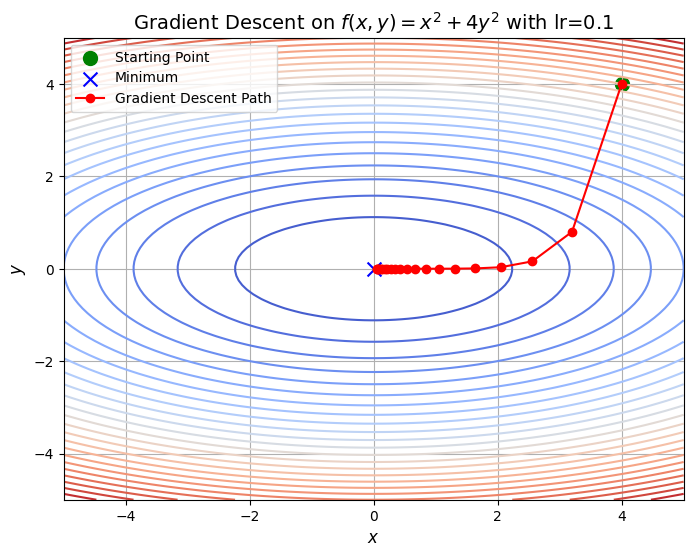

In [10]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation


# Function coefs_1 * w_1**2 + coefs_2 * w_2**2
coefs_torch = torch.tensor([1.0, 4.0], requires_grad=False, dtype=torch.float64)
def function(w):
    return torch.matmul(w**2, coefs_torch)

learning_rate = 0.1
n_iterations = 20

points = run_gd_pytorch(function, learning_rate=learning_rate, n_iterations=n_iterations)

animate_gd(function, points,
           plot_title=f'Gradient Descent on $f(x, y) = x^2 + 4y^2$ with lr={learning_rate}')

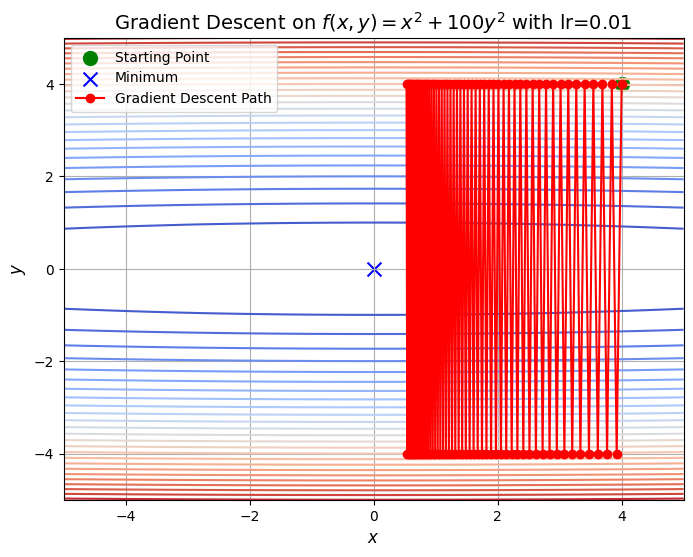

In [11]:
coefs_torch = torch.tensor([1.0, 100.0], requires_grad=False, dtype=torch.float64)
def function(w):
    return torch.matmul(w**2, coefs_torch)

learning_rate = 0.01
n_iterations = 100
points = run_gd_pytorch(function, learning_rate=learning_rate, n_iterations=n_iterations)

animate_gd(function, points,
           plot_title=f'Gradient Descent on $f(x, y) = x^2 + 100y^2$ with lr={learning_rate}')

Ackley function:

$$f(x,y)=-20\exp \left[-0.2{\sqrt{0.5\left(x^{2} + y^{2}\right)}}\right]- \exp\left[ 0.5 ( \cos{2\pi x} + \cos{2\pi y}) \right]$$

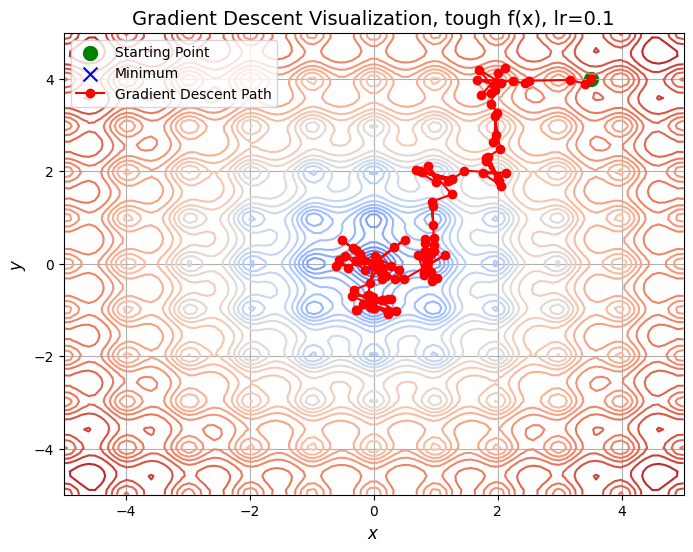

In [12]:
def tough_function(w):
    return (
            -20*torch.exp(-0.2*torch.sqrt((0.5*w**2).sum(axis=-1)))
            - torch.exp(0.5*(torch.cos(2*np.pi*w[...,0]) + torch.cos(2*np.pi*w[...,1])))
            + np.e + 20
    )

learning_rate = 0.1
n_iterations = 100
initial_point = np.array([3.5, 4.0])
points = run_gd_pytorch(tough_function, initial_point=initial_point,
                        learning_rate=learning_rate, n_iterations=n_iterations)

animate_gd(tough_function, points,
           plot_title=f'Gradient Descent Visualization, tough f(x), lr={learning_rate}')

# GD and SGD for linear regression

We'll take a linear regression model $y\sim x_1w_1 + x_2w_2$.

C:\Users\karke\AppData\Local\Temp\ipykernel_8816\1900536680.py:14: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:4483.)
  y = X @ w_true.T + torch.randn(size=(n_points,))*0.5


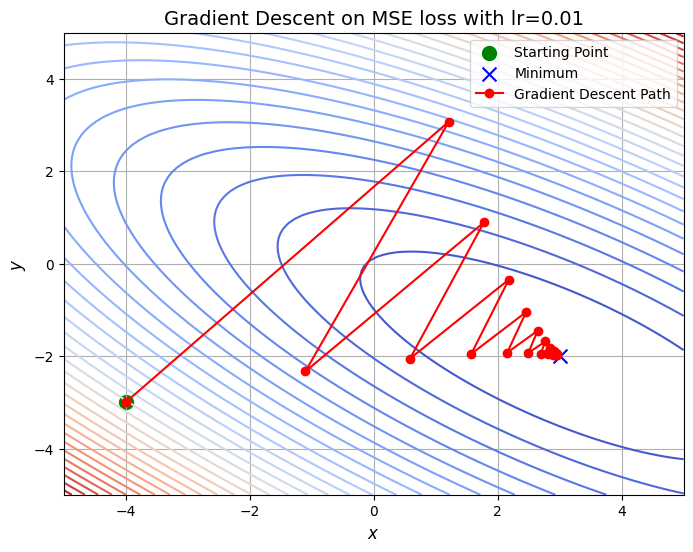

In [13]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation

w_true = torch.tensor([3., -2.], dtype=torch.float64)

n_points = 200
x_base = torch.rand(size=(n_points,1), dtype=torch.float64)*10
X = torch.concat(
    (x_base, x_base + torch.randn(size=(n_points, 1))*5),
    axis=1)
y = X @ w_true.T + torch.randn(size=(n_points,))*0.5

def function(w):
    if len(w.shape) == 1:
        return ((torch.matmul(X, w.T) - y)**2).mean(axis=0)
    else:
        return ((torch.matmul(X, w.T) - y.unsqueeze(-1))**2).mean(axis=0)

learning_rate = 0.01
n_iterations = 20
points = run_gd_pytorch(function,  initial_point=np.array([-4.0, -3.0]),
                        learning_rate=learning_rate, n_iterations=n_iterations)

animate_gd(function, points,
           plot_title=f'Gradient Descent on MSE loss with lr={learning_rate}',
           true_minimum=w_true.detach().numpy())

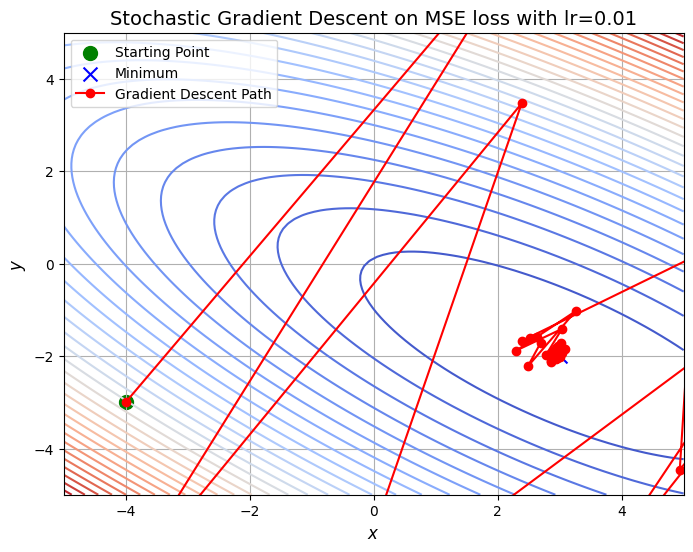

In [14]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation

w_true = torch.tensor([3., -2.], dtype=torch.float64)

n_points = 200
x_base = torch.rand(size=(n_points,1), dtype=torch.float64)*10
X = torch.concat(
    (x_base, x_base + torch.randn(size=(n_points, 1))*5),
    axis=1)
y = X @ w_true.T + torch.randn(size=(n_points,))*0.5

batch_size = 4

def function_sgd(w):
    batch_indices = np.random.choice(n_points, batch_size)
    if len(w.shape) == 1:
        return ((torch.matmul(X[batch_indices,:], w.T) - y[batch_indices])**2).mean(axis=0)
    else:
        return ((torch.matmul(X[batch_indices,:], w.T) - y[batch_indices].unsqueeze(-1))**2).mean(axis=0)

learning_rate = 0.01
n_iterations = 1 * (n_points//batch_size) # potentially to use as much data
points = run_gd_pytorch(function_sgd, initial_point=np.array([-4.0, -3.0]),
                        learning_rate=learning_rate, n_iterations=n_iterations)

animate_gd(function, points,
           plot_title=f'Stochastic Gradient Descent on MSE loss with lr={learning_rate}',
           true_minimum=w_true.detach().numpy())

# How to SGD this with Pytorch in a convenient way

In [15]:
import torch

# Generate random data
n_samples, n_features = 200, 5
X = torch.randn(n_samples, n_features)
w_true = torch.randn(1, n_features) * 5 # True weights
b_true = torch.tensor(-1) # True bias
y = X @ w_true.T + b_true + 0.01 * torch.randn(n_samples, 1)

# Initialize weights and bias
w = torch.randn(1, n_features, requires_grad=True)  # Weight vector
b = torch.randn(1, requires_grad=True)              # Bias scalar

# Define optimizer
# Show explicitly which parameters you want it to optimize
# lr is the learning rate
# This is instead of current_w -= learning_rate * current_w.grad
optimizer = torch.optim.SGD([w, b], lr=0.1)  # Stochastic Gradient Descent

# Training loop
n_epochs = 5
batch_size = 20

# Training loop
for i in range(n_epochs):
    # Shuffle the data at the beginning of each epoch
    perm = torch.randperm(n_samples)

    # Mini-batch training
    for start_idx in range(0, n_samples, batch_size):
        end_idx = start_idx + batch_size
        X_batch = X[perm[start_idx:end_idx]]
        y_batch = y[perm[start_idx:end_idx]]

        # Forward pass: compute predicted y
        y_pred = X_batch @ w.T + b

        # Compute the loss (Mean Squared Error)
        loss = torch.mean((y_pred - y_batch) ** 2)

        # Zero the gradients
        optimizer.zero_grad()

        # Backward pass: compute gradients
        # After that, w and b contain their gradients
        loss.backward()

        # Update weights and bias using the optimizer
        optimizer.step()

    # Optionally print the loss after every epoch
    train_loss = torch.mean((X @ w.T + b - y) ** 2)
    print(f'Epoch {i}, Loss: {train_loss.item()}')

# Final values
print(f'\nTrue weight: {w_true.detach().numpy()}')
print(f'True bias: {b_true.detach().numpy()}')

print(f'\nLearned weight: {w.detach().numpy()}')
print(f'Learned bias: {b.detach().numpy()}')

Epoch 0, Loss: 1.0143333673477173
Epoch 1, Loss: 0.013263183645904064
Epoch 2, Loss: 0.0002705500228330493
Epoch 3, Loss: 8.736292511457577e-05
Epoch 4, Loss: 8.372785669052973e-05

True weight: [[-7.3650813  1.8966444 -1.3147256  7.420256  -1.4536843]]
True bias: -1

Learned weight: [[-7.365174   1.895886  -1.3134462  7.4211493 -1.4530134]]
Learned bias: [-0.9996227]


# An actual classification task

We'll be using a weather dataset that comprises about 10 years of daily weather observations from various locations across Australia. You can either [download it from Kaggle](https://www.kaggle.com/datasets/jsphyg/weather-dataset-rattle-package) or use the google drive download below

Our target variable, `RainTomorrow`, indicates whether it will rain the following day (Yes or No).

Let's investigate the data.

In [18]:
import urllib.request

url = "https://drive.google.com/uc?id=1oDLRJgsOl_s_5FTbmL0XASp0-glW697E"
output = "weatherAUS.csv"
urllib.request.urlretrieve(url, output)

('weatherAUS.csv', <http.client.HTTPMessage at 0x22bbcf0f820>)

In [19]:
import pandas as pd

df = pd.read_csv('weatherAUS.csv')

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  str    
 1   Location       145460 non-null  str    
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  str    
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  str    
 10  WindDir3pm     141232 non-null  str    
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null   float64


Now let's do it Pytorch-style and select the optimal coefficient of $L_2$-regularization.

In [22]:
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


# =========================
# 1. Loading and reporting
# =========================

def load_weather_data(
    file_path: str,
    target_col: str = "RainTomorrow",
    drop_cols: tuple[str, ...] = ("Date",),
):
    df = pd.read_csv(file_path)

    if target_col in df.columns and df[target_col].dtype == object:
        df[target_col] = df[target_col].map({"No": 0, "Yes": 1})

    df = df.dropna(subset=[target_col]).copy()

    X = df.drop(columns=[target_col, *drop_cols], errors="ignore")
    y = df[target_col].astype(np.float32)

    return X, y


def report_class_balance(y, name="dataset"):
    y_series = pd.Series(y)
    counts = y_series.value_counts().sort_index()
    shares = y_series.value_counts(normalize=True).sort_index()

    report = pd.DataFrame({
        "count": counts,
        "share": shares,
    })

    print(f"\nClass balance for {name}:")
    print(report)


# =========================
# 2. Preprocessor
# =========================

def build_default_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
    numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
    categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    try:
        categorical_encoder = OneHotEncoder(
            drop="first",
            handle_unknown="ignore",
            sparse_output=False,
        )
    except TypeError:
        # older sklearn
        categorical_encoder = OneHotEncoder(
            drop="first",
            handle_unknown="ignore",
            sparse=False,
        )

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", categorical_encoder),
    ])

    return ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features),
        ]
    )


def preprocess_split(X_train, X_eval, y_train, y_eval, preprocessor):
    fitted_preprocessor = clone(preprocessor)

    X_train_features = fitted_preprocessor.fit_transform(X_train)
    X_eval_features = fitted_preprocessor.transform(X_eval)

    X_train_features = np.asarray(X_train_features, dtype=np.float32)
    X_eval_features = np.asarray(X_eval_features, dtype=np.float32)

    y_train_values = np.asarray(y_train, dtype=np.float32).reshape(-1, 1)
    y_eval_values = np.asarray(y_eval, dtype=np.float32).reshape(-1, 1)

    feature_names = fitted_preprocessor.get_feature_names_out()

    return (
        X_train_features,
        X_eval_features,
        y_train_values,
        y_eval_values,
        fitted_preprocessor,
        feature_names,
    )


# =========================
# 3. Training config
# =========================

@dataclass
class TrainingConfig:
    batch_size: int = 256
    n_epochs: int = 5
    optimizer_cls: type = torch.optim.SGD
    optimizer_kwargs: dict = field(default_factory=lambda: {"lr": 0.05})


# =========================
# 4. Model
# =========================

class LogisticRegressionModel:
    def __init__(self, l1: float = 0.0, l2: float = 0.0, fit_intercept: bool = True):
        self.l1 = l1
        self.l2 = l2
        self.fit_intercept = fit_intercept

        self.coef_ = None
        self.intercept_ = None

    def initialize(self, n_features: int):
        self.coef_ = torch.zeros((1, n_features), dtype=torch.float32, requires_grad=True)

        if self.fit_intercept:
            self.intercept_ = torch.zeros((1,), dtype=torch.float32, requires_grad=True)
        else:
            self.intercept_ = torch.zeros((1,), dtype=torch.float32, requires_grad=False)

    def parameters(self):
        params = [self.coef_]
        if self.fit_intercept:
            params.append(self.intercept_)
        return params

    def infer_tensor(self, X_tensor: torch.Tensor) -> torch.Tensor:
        return X_tensor @ self.coef_.T + self.intercept_

    def infer(self, X_features, return_tensor=False):
        X_tensor = torch.as_tensor(X_features, dtype=torch.float32)
        raw_output = self.infer_tensor(X_tensor)

        if return_tensor:
            return raw_output
        return raw_output.detach().numpy().ravel()

    def predict_proba(self, X_features, return_raw_output=False):
        raw_output = self.infer(X_features, return_tensor=True)
        probs_pos = torch.sigmoid(raw_output).detach().numpy().ravel()
        probs = np.column_stack([1.0 - probs_pos, probs_pos])

        if return_raw_output:
            return probs, raw_output
        return probs

    def predict(self, X_features=None, probs=None):
        if probs is None:
            probs = self.predict_proba(X_features)
        return (probs[:, 1] >= 0.5).astype(int)

    def regularization_penalty(self) -> torch.Tensor:
        penalty = torch.tensor(0.0, dtype=torch.float32)

        if self.l1 > 0:
            penalty = penalty + self.l1 * torch.sum(torch.abs(self.coef_))

        if self.l2 > 0:
            penalty = penalty + self.l2 * torch.sum(self.coef_ ** 2)

        return penalty

    def data_loss(self, raw_output: torch.Tensor, y_tensor: torch.Tensor) -> torch.Tensor:
        return F.binary_cross_entropy_with_logits(raw_output, y_tensor)

    def training_loss(self, raw_output: torch.Tensor, y_tensor: torch.Tensor) -> torch.Tensor:
        return self.data_loss(raw_output, y_tensor) + self.regularization_penalty()


# =========================
# 5. Evaluation
# =========================


def evaluate(model: LogisticRegressionModel, X_features, y_values):
    probs, raw_output = model.predict_proba(X_features, return_raw_output=True)
    preds = model.predict(probs=probs)

    y_true = y_values.ravel().astype(int)
    y_tensor = torch.as_tensor(y_values, dtype=torch.float32)

    loss = model.data_loss(raw_output, y_tensor).item()
    cm = confusion_matrix(y_true, preds)

    result = {
        "loss": loss,
        "accuracy": accuracy_score(y_true, preds),
        "f1": f1_score(y_true, preds),
        "roc_auc": roc_auc_score(y_true, probs[:, 1]),
        "confusion_matrix": cm,
        "predictions": preds,
        "probabilities": probs[:, 1],
    }

    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        result["tn"] = tn
        result["fp"] = fp
        result["fn"] = fn
        result["tp"] = tp

    return result

def confusion_matrix_frame(cm, negative_label="no_rain", positive_label="rain"):
    return pd.DataFrame(
        cm,
        index=[f"actual_{negative_label}", f"actual_{positive_label}"],
        columns=[f"pred_{negative_label}", f"pred_{positive_label}"],
    )


# =========================
# 6. Training
# =========================

def fit_model(
    model: LogisticRegressionModel,
    X_train_features,
    y_train_values,
    training_config: TrainingConfig,
    X_eval_features=None,
    y_eval_values=None,
    verbose=True,
):
    n_samples, n_features = X_train_features.shape

    model.initialize(n_features)

    X_train_tensor = torch.tensor(X_train_features, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train_values, dtype=torch.float32)

    optimizer = training_config.optimizer_cls(
        model.parameters(),
        **training_config.optimizer_kwargs,
    )

    history = {
        "train_loss": [],
        "eval_loss": [],
        "eval_accuracy": [],
        "eval_f1": [],
        "eval_auc": [],
    }

    for epoch in range(training_config.n_epochs):
        perm = torch.randperm(n_samples)

        for start in range(0, n_samples, training_config.batch_size):
            idx = perm[start:start + training_config.batch_size]
            xb = X_train_tensor[idx]
            yb = y_train_tensor[idx]

            raw_output = model.infer_tensor(xb)
            loss = model.training_loss(raw_output, yb)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        train_metrics = evaluate(model, X_train_features, y_train_values)
        history["train_loss"].append(train_metrics["loss"])

        if X_eval_features is not None and y_eval_values is not None:
            eval_metrics = evaluate(model, X_eval_features, y_eval_values)

            history["eval_loss"].append(eval_metrics["loss"])
            history["eval_accuracy"].append(eval_metrics["accuracy"])
            history["eval_f1"].append(eval_metrics["f1"])
            history["eval_auc"].append(eval_metrics["roc_auc"])

            if verbose:
                print(
                    f"Epoch {epoch + 1:02d} | "
                    f"train_loss={train_metrics['loss']:.4f} | "
                    f"eval_loss={eval_metrics['loss']:.4f} | "
                    f"eval_acc={eval_metrics['accuracy']:.4f} | "
                    f"eval_f1={eval_metrics['f1']:.4f} | "
                    f"eval_auc={eval_metrics['roc_auc']:.4f}"
                )
        else:
            if verbose:
                print(
                    f"Epoch {epoch + 1:02d} | "
                    f"train_loss={train_metrics['loss']:.4f}"
                )

    return history



In [23]:
# =========================
# 7. Run the experiment properly: train / val / test
# =========================

# Load data
X, y = load_weather_data(
    "weatherAUS.csv",
    target_col="RainTomorrow",
    drop_cols=("Date",),
)

report_class_balance(y, "full data")

# First split off the test set
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

# Then split the remaining part into train and val
# 0.25 of 0.8 = 0.2 of the whole dataset, so this gives 60/20/20
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,
    random_state=42,
    stratify=y_train_val,
)

report_class_balance(y_train, "train")
report_class_balance(y_val, "val")
report_class_balance(y_test, "test")

# -------------------------------------------------
# Hyperparameter selection on train / val
# -------------------------------------------------

preprocessor = build_default_preprocessor(X_train)

(
    X_train_features,
    X_val_features,
    y_train_values,
    y_val_values,
    fitted_preprocessor_for_selection,
    feature_names_for_selection,
) = preprocess_split(
    X_train,
    X_val,
    y_train,
    y_val,
    preprocessor,
)

print("\nTrain shape after preprocessing:", X_train_features.shape)
print("Val shape after preprocessing:   ", X_val_features.shape)

training_config = TrainingConfig(
    batch_size=256,
    n_epochs=5,
    optimizer_cls=torch.optim.SGD,
    optimizer_kwargs={"lr": 0.05},
)

l2_grid = [0.0, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0]

selection_rows = []
best_l2 = None
best_val_auc = -np.inf

for l2 in l2_grid:
    model = LogisticRegressionModel(
        l1=0.0,
        l2=l2,
        fit_intercept=True,
    )

    history = fit_model(
        model,
        X_train_features,
        y_train_values,
        training_config,
        X_eval_features=X_val_features,
        y_eval_values=y_val_values,
        verbose=False,
    )

    train_metrics = evaluate(model, X_train_features, y_train_values)
    val_metrics = evaluate(model, X_val_features, y_val_values)

    selection_rows.append({
        "l2": l2,
        "train_loss": train_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "train_f1": train_metrics["f1"],
        "train_auc": train_metrics["roc_auc"],
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_f1": val_metrics["f1"],
        "val_auc": val_metrics["roc_auc"],
    })

    print(
        f"l2={l2:<7g} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_acc={val_metrics['accuracy']:.4f} | "
        f"val_f1={val_metrics['f1']:.4f} | "
        f"val_auc={val_metrics['roc_auc']:.4f}"
    )

    if val_metrics["roc_auc"] > best_val_auc:
        best_val_auc = val_metrics["roc_auc"]
        best_l2 = l2

selection_table = pd.DataFrame(selection_rows).sort_values("val_auc", ascending=False)

print("\n=== L2 selection results ===")
print(selection_table.to_string(index=False))

print(f"\nBest l2 by val_auc: {best_l2}")

# -------------------------------------------------
# Refit on train + val with the selected l2
# -------------------------------------------------

preprocessor_final = build_default_preprocessor(X_train_val)

(
    X_train_val_features,
    X_test_features,
    y_train_val_values,
    y_test_values,
    fitted_preprocessor_final,
    feature_names_final,
) = preprocess_split(
    X_train_val,
    X_test,
    y_train_val,
    y_test,
    preprocessor_final,
)

print("\nTrain+val shape after preprocessing:", X_train_val_features.shape)
print("Test shape after preprocessing:     ", X_test_features.shape)

best_model = LogisticRegressionModel(
    l1=0.0,
    l2=best_l2,
    fit_intercept=True,
)

final_history = fit_model(
    best_model,
    X_train_val_features,
    y_train_val_values,
    training_config,
    X_eval_features=None,
    y_eval_values=None,
    verbose=True,
)

# -------------------------------------------------
# Final test evaluation
# -------------------------------------------------

train_val_metrics = evaluate(best_model, X_train_val_features, y_train_val_values)
test_metrics = evaluate(best_model, X_test_features, y_test_values)

print("\n=== Final metrics ===")
print(
    f"Train+val: loss={train_val_metrics['loss']:.4f}, "
    f"acc={train_val_metrics['accuracy']:.4f}, "
    f"f1={train_val_metrics['f1']:.4f}, "
    f"auc={train_val_metrics['roc_auc']:.4f}"
)
print(
    f"Test:      loss={test_metrics['loss']:.4f}, "
    f"acc={test_metrics['accuracy']:.4f}, "
    f"f1={test_metrics['f1']:.4f}, "
    f"auc={test_metrics['roc_auc']:.4f}"
)

print("\nTest confusion matrix:")
print(confusion_matrix_frame(test_metrics["confusion_matrix"]))

print("\nBias:")
print(best_model.intercept_.detach().numpy())

coef_table = pd.DataFrame({
    "feature": feature_names_final,
    "coefficient": best_model.coef_.detach().numpy().ravel(),
})
coef_table["abs_coefficient"] = coef_table["coefficient"].abs()

print("\nTop coefficients:")
print(
    coef_table.sort_values("abs_coefficient", ascending=False)
              .head(15)[["feature", "coefficient"]]
              .to_string(index=False)
)

ValueError: could not convert string to float: 'No'

As you see, the confusion matrix is quite dismal, so superior feature engineering is needed!

# The computational problems of softmax and log loss

In this section we'll see that only bad things happen when you compute softmax + log loss naively.

**Example 1. Too large logits**

In [ ]:
import torch
import torch.nn.functional as F

torch.set_printoptions(precision=6, sci_mode=False)

logits1 = torch.tensor([[1000.0, 1001.0, 999.0]])
target1 = torch.tensor([1])

print("Example 1 logits:")
print(logits1)

A naive version: softmax + log loss

$$\text{softmax}(x_1,\ldots,x_K) = \left(
\frac{e^{x_1}}{\sum_je^{x_j}},\ldots,\frac{e^{x_K}}{\sum_je^{x_j}}
\right)$$

$$
\mathcal{L} = -\log(\text{softmax}(x_1,\ldots,x_K)[true\_class])
$$

In [ ]:
exp_logits1 = torch.exp(logits1)
probs1_naive = exp_logits1 / exp_logits1.sum(dim=1, keepdim=True)
loss1_naive = -torch.log(probs1_naive[0, target1])

print("\nNaive exp(logits):")
print(exp_logits1)
print("Naive softmax:")
print(probs1_naive)
print("Naive loss:")
print(loss1_naive)

Why this happens? First of all, because the exponent gets too large arguments.

The first thing you should do is to subtract maximum from logits before the softmax:

$$m = \text{argmax}_jx_j$$

$$\text{softmax}(x_1,\ldots,x_K) = \left(
\frac{e^{x_1 - x_m}}{\sum_je^{x_j - x_m}},\ldots,\frac{e^{x_K - x_m}}{\sum_je^{x_j - x_m}}
\right)$$

No more infinite exponents!

In [ ]:
shifted1 = logits1 - logits1.max(dim=1, keepdim=True).values
exp_shifted1 = torch.exp(shifted1)
probs1_stable = exp_shifted1 / exp_shifted1.sum(dim=1, keepdim=True)
loss1_stable = -torch.log(probs1_stable[0, target1])

print("\nShifted logits (subtract row max):")
print(shifted1)
print("Stable softmax after subtracting max:")
print(probs1_stable)
print("Stable softmax + log loss:")
print(loss1_stable)

**Example 2. Too different logits**

In [ ]:
logits2 = torch.tensor([[-1000.0, 0.0, 1000.0]])
target2 = torch.tensor([0])

print("\n\nExample 2 logits:")
print(logits2)

Here, subtraction of maximum doesn't help: some logits become too small, their exponent hitting zero, which raises `NaN` under logarithm:

In [ ]:
shifted2 = logits2 - logits2.max(dim=1, keepdim=True).values
exp_shifted2 = torch.exp(shifted2)
probs2_stable = exp_shifted2 / exp_shifted2.sum(dim=1, keepdim=True)
loss2_stable = -torch.log(probs2_stable[0, target2])

print("\nShifted logits:")
print(shifted2)
print("Stable softmax:")
print(probs2_stable)
print("Stable softmax + log loss:")
print(loss2_stable)

The solution is to use **logsoftmax** instead of softmax. Indeed, is it even reasonable to compute log of exp?

$$\log\left(
\frac{e^{x_i}}{\sum_je^{x_j}}  
\right) = x_i - \log\left(\sum_je^{x_j}\right)$$

The sum of exponents is unlikely zero, so everything should work well.

$$\text{logsoftmax} = \left(x_1 - \log\left(\sum_je^{x_j}\right),\ldots, x_K - \log\left(\sum_je^{x_j}\right)\right)$$

And on top of that, we use NLL loss which doesn't have logarithm.

In [ ]:
row_max = logits2.max(dim=1, keepdim=True).values
shifted = logits2 - row_max
logsumexp = torch.log(torch.exp(shifted).sum(dim=1, keepdim=True))
logsoftmax = shifted - logsumexp

print("\nlogsoftmax = log_softmax(logits):")
print(logsoftmax)

batch_indices = torch.arange(logits2.shape[0])
target_log_probs = logsoftmax[batch_indices, target2]
losses = -target_log_probs
mean_loss = losses.mean()

print("\nNLL loss:")
print(mean_loss)

Here are some ways of doing this with library functions:

In [ ]:
log_probs2 = F.log_softmax(logits2, dim=1)
loss2_nll = F.nll_loss(log_probs2, target2)

print("\nlog_softmax(logits):")
print(log_probs2)
print("NLL loss from log_softmax:")
print(loss2_nll)

In [ ]:
loss2_ce = F.cross_entropy(logits2, target2)
print("\nCross-entropy directly from logits:")
print(loss2_ce)